# Zadanie 1 modułu 3

In [20]:
import numpy as np
import cvxpy as cp
import scipy.io
import matplotlib.pyplot as plt
from scipy.optimize import linprog

### Wczytanie danych

In [21]:
# Wczytanie danych
data = scipy.io.loadmat('Data01.mat')
data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Mon Mar 23 19:01:39 2020',
 '__version__': '1.0',
 '__globals__': [],
 't': array([[ 0.  ],
        [ 0.01],
        [ 0.02],
        ...,
        [ 9.98],
        [ 9.99],
        [10.  ]], shape=(1001, 1)),
 'y': array([[0.24928658],
        [0.13381062],
        [0.09438766],
        ...,
        [0.17569244],
        [0.14001862],
        [0.17109012]], shape=(1001, 1))}

In [22]:
t = data['t'].flatten()
y = data['y'].flatten()
print("t:", t)
print("y:", y)

t: [ 0.    0.01  0.02 ...  9.98  9.99 10.  ]
y: [0.24928658 0.13381062 0.09438766 ... 0.17569244 0.14001862 0.17109012]


### Rozwiązanie zadania

#### Problem (7)

In [23]:
n = len(y)
m = n - 1
q = 1.5

# 1. Wektor kosztów c
# Chcemy minimalizować sumę xi (błędów), więc wagi dla v i delta to 0
c = np.concatenate([np.zeros(n), np.ones(n), np.zeros(m)])

# 2. Budowa macierzy ograniczeń A
In = np.eye(n)
Im = np.eye(m)
# Macierz D
D = np.zeros((m, n))
for i in range(m):
    D[i, i] = -1
    D[i, i+1] = 1

# Macierz A
A = np.block([
    [ In, -In,  np.zeros((n, m))],  # v - xi <= y_tilde 
    [-In, -In,  np.zeros((n, m))],  # -v - xi <= -y_tilde 
    [ D,  np.zeros((m, n)), -Im],   # Dv - delta <= 0
    [-D,  np.zeros((m, n)), -Im],   # -Dv - delta <= 0
    [ np.zeros((1, n)), np.zeros((1, n)), np.ones((1, m))] # suma delta <= q
])

# 3. Wektor prawej strony b
b = np.concatenate([y, -y, np.zeros(m), np.zeros(m), [q]])

# 4. Rozwiązanie
res = linprog(c, A_ub=A, b_ub=b, bounds=(None, None))
v7 = res.x[:n]

#### Problem (8)

In [25]:
n = len(y)
m = n - 1
tau = 10 

# 1. Wektor kosztów c
c_8 = np.concatenate([
    np.zeros(n),
    np.ones(n),
    tau * np.ones(m)
])

# 2. Budowa macierzy ograniczeń A
In = np.eye(n)
Im = np.eye(m)
D = np.zeros((m, n))
for i in range(m):
    D[i, i] = -1
    D[i, i+1] = 1

# Macierz A
A_8 = np.block([
    [ In, -In,  np.zeros((n, m))],  #  v - xi <=  y_tilde
    [-In, -In,  np.zeros((n, m))],  # -v - xi <= -y_tilde
    [ D,  np.zeros((m, n)), -Im],   #  Dv - delta <= 0
    [-D,  np.zeros((m, n)), -Im]    # -Dv - delta <= 0
])

# 3. Wektor prawej strony b
b_8 = np.concatenate([
    y,           # dla v - xi <= y_tilde
    -y,          # dla -v - xi <= -y_tilde
    np.zeros(m), # dla Dv - delta <= 0
    np.zeros(m)  # dla -Dv - delta <= 0
])

# 4. Rozwiązanie
res_8 = linprog(c_8, A_ub=A_8, b_ub=b_8, bounds=(None, None))

# Wyciągnięcie estymaty v
v8 = res_8.x[:n]

### Wykres

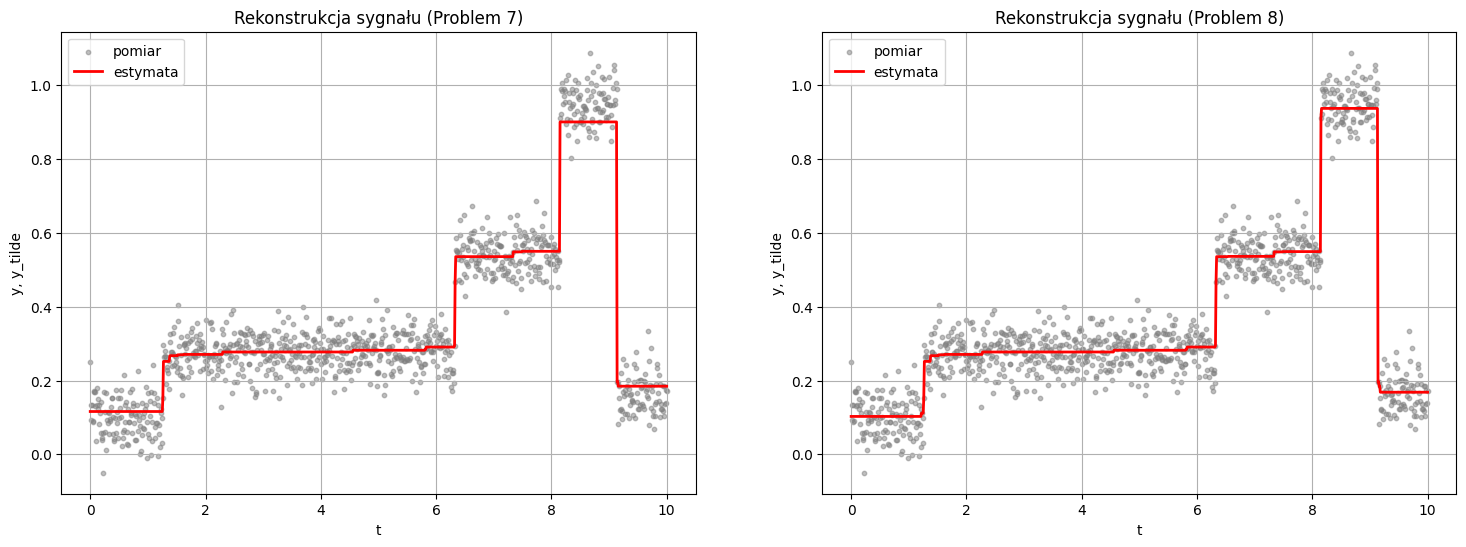

In [26]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.scatter(t, y, color='gray', alpha=0.5, s=10, label='pomiar')
plt.plot(t, v7, color='red', linewidth=2, label='estymata')
plt.xlabel('t')
plt.ylabel('y, y_tilde')
plt.title('Rekonstrukcja sygnału (Problem 7)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(t, y, color='gray', alpha=0.5, s=10, label='pomiar')
plt.plot(t, v8, color='red', linewidth=2, label='estymata')
plt.xlabel('t')
plt.ylabel('y, y_tilde')
plt.title('Rekonstrukcja sygnału (Problem 8)')
plt.legend()
plt.grid(True)
plt.show()